# INFO-6146 – In-class Activity #1 (10 Marks)
# Dataset: California Housing
# Objective: Assess understanding of model architecture, loss functions, training process and evaluation.

Author: Yun-Jiung Wang

Student Number: 1256222

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

# SECTION 1 – LOAD DATA

data = fetch_california_housing()

X = data.data
y = data.target

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (20640, 8)
Target shape: (20640,)


In [ ]:
# SECTION 2 – TRAIN TEST SPLIT (FILL IN THE BLANKS)
# QUESTION 1 (1 mark):Choose an appropriate test_size and explain in comments why you selected it.
# Reason: It is common to split as 80/20 for train and test dataset.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.8, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 4128
Test samples: 16512


In [ ]:
# SECTION 3 – BUILD MODEL (FILL IN THE BLANKS)
# QUESTION 2(1 mark): Build a regression model with One hidden layer with appropriate number of neurons and activation function
# Explain your choices in comments.

# I choice 8 for neurons and relu for activation function.
# 8 neurons is because the dataset has only 8 features, neurons should not be too lage
# 'ReLU' helps with non-linearity and avoids vanishing gradients.

model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(1)
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,281 (5.00 KB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# SECTION 4 – COMPILE MODEL (FILL IN THE BLANKS)
# QUESTION 3(1 mark): Define the optimizer, loss function and metric
# Explain why you chose them in comments.

# adam is a faster optimizer
# For continuse dataset, MSE is a good choice to check the loss
# For the mettics: RMSE is sensitivity to large Errors.

model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=[tf.keras.metrics.RootMeanSquaredError()]
)

In [ ]:
# SECTION 5 – TRAIN MODEL (FILL IN THE BLANKS)
# QUESTION 4(1 mark): Select the number epochs, batch_size and validation_split
# Explain why you picked those values in comments.

# validation_split =.02 (refer to test data split as 80/20)
# epochs = 50 (refer to the SECTION 8 – MODEL IMPROVEMENT, epoch=50, to make the result comparable, and in the same standard)
# batch_size=32, after selecting serveral values, the loss between train and validate is the best for SECTION 6 – PLOT LOSS CURVES (FILL IN THE BLANKS)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=0
)

print("Training complete.")

Training complete.


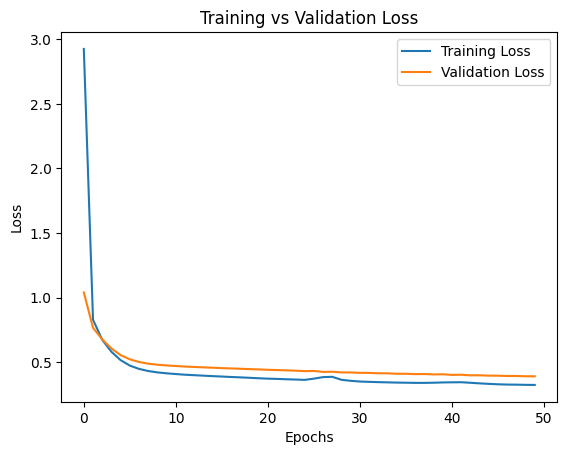

In [ ]:
# SECTION 6 – PLOT LOSS CURVES (FILL IN THE BLANKS)
# QUESTION 5(1 mark): Plot training loss and validation loss.
# Comment on whether the model is overfitting or underfitting?

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

Observation:

The model is neither overfitting nore unfitting.

From the graph above, we could find out that the loss decreasing rate slows down to approximately not lower after epoch =30. Means that epochs can be down to 30~35.

In [ ]:
# SECTION 7 – MODEL EVALUATION (FILL IN THE BLANKS)
# QUESTION 6(2 marks): Evaluate the model on test data and explain what the results indicate.

# Re-compile the model defensively in case of kernel state inconsistency
model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=[tf.keras.metrics.RootMeanSquaredError()]
)

test_loss, test_metric = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Metric (RMSE):", test_metric)

516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3482 - root_mean_squared_error: 0.5900
Test Loss: 0.3419843316078186
Test Metric (RMSE): 0.584794282913208


Observation:

The test loss is not bad (0.34), however, the RMSE is 0.58, which is not good.

In [ ]:
# SECTION 8 – MODEL IMPROVEMENT
# QUESTION 7 (2 marks): Add another hidden layer (64 neurons).
# Keep the same activation function as used previously.
# Compare performance and explain the difference.
# ============================================================

model_2 = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(32, activation="relu"),
    Dense(1)
])

model_2.compile(
    optimizer="adam",
    loss="mse"
)

history_2 = model_2.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    verbose=0
)

print("Model 2 trained.")

# Compare the model1, this runs faster. Even have more layers. Maybe the colab remebers the previous one.

Model 2 trained.


In [ ]:
# SECTION 9 – ACTIVATION FUNCTION CHANGE
# QUESTION 8(1 mark): Replace the activation function with a different one.
# Observe training behaviour and explain the difference.

# Sigmoid is another activation we had learned, it controls the shape for every ouput layer.
# Adam update every wieights

model_3 = Sequential([
    Dense(32, activation="sigmoid", input_shape=(X_train.shape[1],)),
    Dense(1)
])

model_3.compile(
    optimizer="adam",
    loss="mse"
)

history_3 = model_3.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    verbose=0
)

print("Model 3 trained.")

# Add your reflections as comments at each stage in the code.

Model 3 trained.
